In [1]:
cd("/home/ritaferi/Phd/SSDdev/")
using Pkg
Pkg.activate(".")
Pkg.instantiate()

using SolidStateDetectors
using Unitful
using Plots
using LegendHDF5IO
using HDF5



  Activating project at `~/Phd/SSDdev`


In [2]:
using Random
using SpecialFunctions
using Distributions

-----------

## detector

name: TrueCoaxial
units:
  length: mm
  angle: deg
  potential: V
  temperature: K
grid:
  coordinates: cylindrical
  axes:
    r:
      to: 10.01
      boundaries: inf
    phi:
      from: 0
      to: 0
      boundaries:
        left: periodic
        right: periodic
    z:
      from: -0.01
      to: 10.01
      boundaries:
        left: inf
        right: inf
medium: vacuum
detectors:
- semiconductor:
    material: HPGe
    temperature: 90
    impurity_density:
      name: PtypePNjunction
      lithium_annealing_temperature: 623K
      lithium_annealing_time: 18minute
      doped_contact_id: 2
      bulk_impurity_density:
        name: constant
        value: -1e10cm^-3
    charge_drift_model:
      model: InactiveLayerChargeDriftModel
      temperature: 90K
      neutral_impurity_density:
        name: constant
        value: 5.6769e15cm^-3
      # # Uncomment the following lines if you want to use different bulk and surface impurity densities in the charge_drift_model section
    

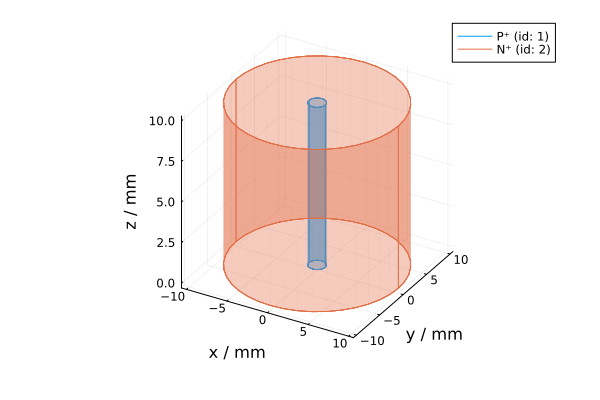

In [11]:
det_rin = 1u"mm"
det_z = det_r = 10u"mm"
z_draw = det_z/2
pn_r = 8.957282u"mm" # this one was calculated by searching the zero impurity point (displayed in the following section)

T = Float64;
sim = Simulation{T}(SSD_examples[:TrueCoaxial])
cfn = SSD_examples[:TrueCoaxial]
print(open(f -> read(f, String), cfn))
plot(sim.detector, xunit = u"mm", yunit = u"mm", zunit = u"mm")

--------------

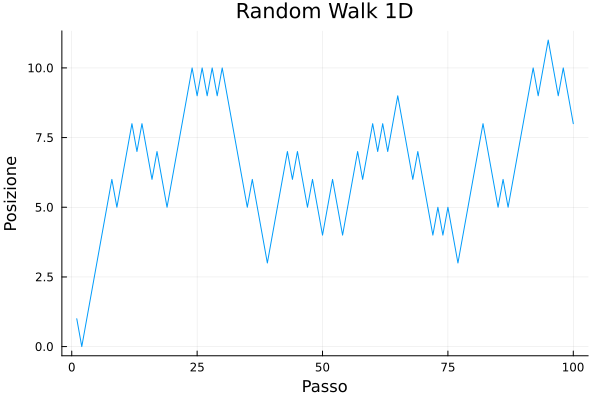

In [7]:
#1D
function random_walk_1d(N; l=1.0)
    steps = rand([-l, l], N)        # genera N passi ±l
    x = cumsum(steps)               # posizione nel tempo
    return x
end

# Parametri
N = 100
x = random_walk_1d(N)

plot(x,
     xlabel="Passo",
     ylabel="Posizione",
     title="Random Walk 1D",
     legend=false)

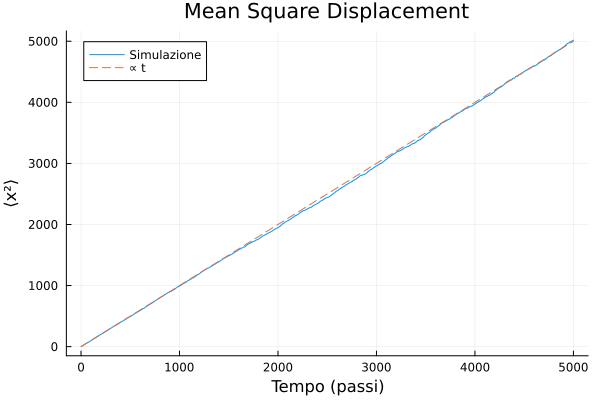

In [10]:
#2D
using Statistics

function ensemble_mean_square(N, M; l=1.0)
    msd = zeros(N)

    for m in 1:M
        x = random_walk_1d(N, l=l)
        msd .+= x.^2
    end

    return msd ./ M
end

N = 5000       # passi
M = 10000       # numero di traiettorie

msd = ensemble_mean_square(N, M)

plot(1:N, msd,
     xlabel="Tempo (passi)",
     ylabel="⟨x²⟩",
     title="Mean Square Displacement",
     label="Simulazione")

plot!(1:N, (1:N), linestyle=:dash, label="∝ t")